# Exploratory Data Analysis — House Oversight Epstein Estate Production

DSAN-6400 final project · Phase 0 (before corpus construction)

**Production:** `HOUSE_OVERSIGHT_009`, released by the House Committee on Oversight and
Government Reform (produced 2025-11-11). Delivered as a standard eDiscovery package:

| Archive | Contents |
|---|---|
| `DATA.zip` | Concordance `.dat` load file (one row per document) + Opticon `.opt` image cross-reference (one row per page) |
| `TEXT.zip` | Extracted / OCR'd text, one `.txt` per document, named by beginning Bates number |
| `NATIVES.zip` | Native files for a handful of documents (mostly spreadsheets, one video) |

**What this notebook answers, in the order the project needs it:**

1. How much material is there, and what is the unit of analysis?
2. How complete is the shipped metadata — can the knowledge graph lean on it? *(Phase 1)*
3. How good is the text? Which documents are usable for NER at all? *(Phase 1 → 2)*
4. What kinds of documents are these, and what time span do they cover?
5. **Is there structure we can extract cheaply and reliably before touching an LLM?** *(Phase 2)*
6. What does all of this imply for chunking, entity resolution, and evaluation? *(Phases 1–4)*

Everything below reads from `data/processed/manifest.parquet`, built by
`scripts/build_manifest.py`.

In [1]:
import re, sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")

from src.ingestion.loadfile import Production, load_text, read_dat, read_opt
from src.ingestion.textstats import DOC_TYPE_PATTERNS, strip_bates

RAW = REPO / "data" / "raw" / "extracted"
PROC = REPO / "data" / "processed"
FIGS = REPO / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

In [2]:
# Plot styling: one fixed categorical order (never cycled), a single sequential hue,
# recessive axes. Colours are the validated default palette from the dataviz skill.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = "#2a78d6"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#d9d8d2"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlecolor": INK,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "font.size": 9,
    "legend.frameon": False,
    "lines.linewidth": 2,
})
for spine in ("top", "right"):
    plt.rcParams[f"axes.spines.{spine}"] = False


def save(fig, name):
    """Save a figure to results/figures and return it for inline display."""
    fig.tight_layout()
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight", facecolor="white")
    return fig

---
## 1. Production inventory

The load file defines the unit of analysis: **a document**, keyed by its beginning Bates
number, spanning one or more page images. Everything else in the project — chunks, entity
mentions, graph edge evidence — has to cite back to that key.

In [3]:
manifest = pd.read_parquet(PROC / "manifest.parquet")
stats = pd.read_parquet(PROC / "text_stats.parquet").set_index("doc_id")
docs = manifest.set_index("doc_id").join(stats)

n_docs = len(docs)
n_pages = int(docs["image_pages"].sum())
n_words = int(docs["n_words"].sum())

print(f"documents          {n_docs:>10,}")
print(f"page images        {n_pages:>10,}")
print(f"documents w/ text  {int(docs['has_text'].sum()):>10,}  ({docs['has_text'].mean():.1%})")
print(f"total words        {n_words:>10,}")
print(f"total characters   {int(docs['n_chars'].sum()):>10,}")
print(f"native files       {int(docs['has_native'].sum()):>10,}")
print(f"Bates range        {docs.index.min()} .. {docs.index.max()}")

documents               2,897
page images            23,124
documents w/ text       2,895  (99.9%)
total words         7,299,554
total characters   55,573,544
native files               11
Bates range        HOUSE_OVERSIGHT_010477 .. HOUSE_OVERSIGHT_033599


count    2897.0
mean        8.0
std        30.6
min         1.0
25%         1.0
50%         2.0
75%         4.0
max       487.0

single-page documents: 1,019 (35.2%)
documents ≥ 50 pages:  79 — 50.5% of all pages


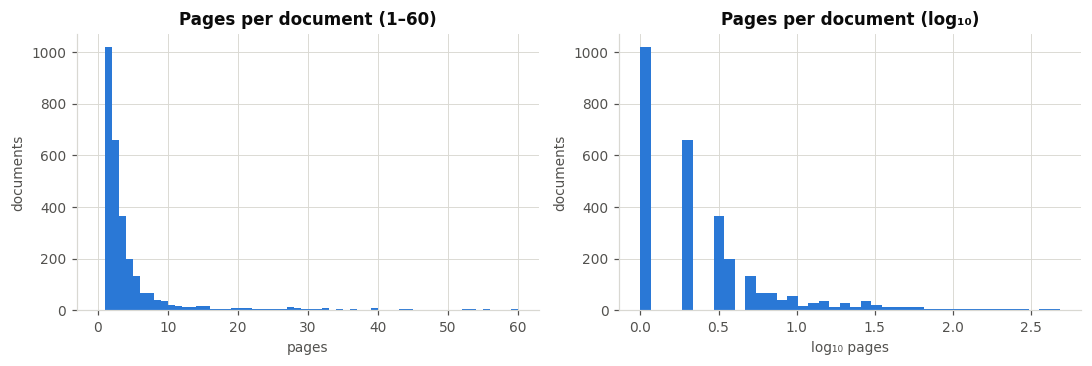

In [4]:
# Pages per document: heavily skewed, which matters for chunking budget.
pages = docs["image_pages"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(pages, bins=np.arange(0, 61, 1), color=SEQ)
axes[0].set(title="Pages per document (1–60)", xlabel="pages", ylabel="documents")
axes[1].hist(np.log10(pages), bins=40, color=SEQ)
axes[1].set(title="Pages per document (log₁₀)", xlabel="log₁₀ pages", ylabel="documents")
save(fig, "01_pages_per_doc")

print(pages.describe().round(1).to_string())
print(f"\nsingle-page documents: {(pages == 1).sum():,} ({(pages == 1).mean():.1%})")
print(f"documents ≥ 50 pages:  {(pages >= 50).sum():,} — {(pages[pages >= 50].sum() / pages.sum()):.1%} of all pages")

---
## 2. How complete is the shipped metadata?

This is the decisive question for Phase 2. If the load file carried populated
`Email From` / `Email To` / `Date Sent` fields for the whole production, a large part of
the knowledge graph would be a `groupby` away.

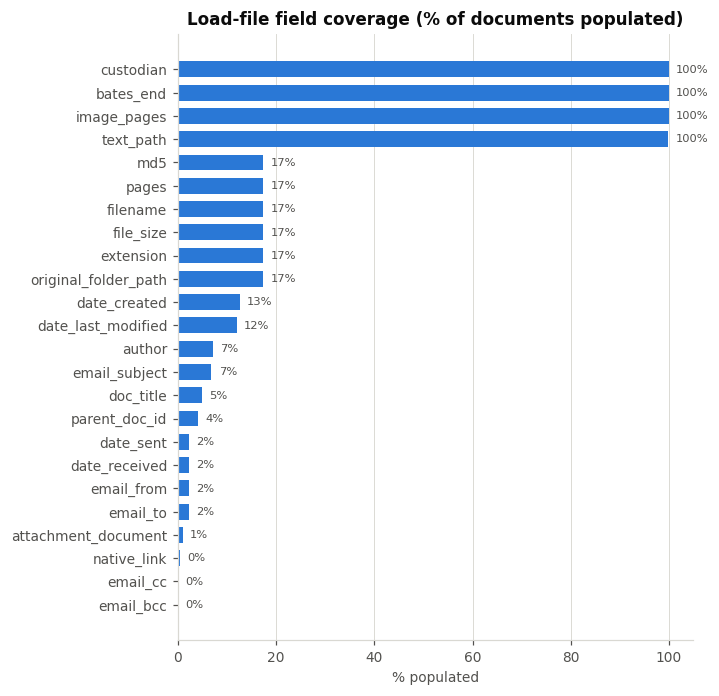

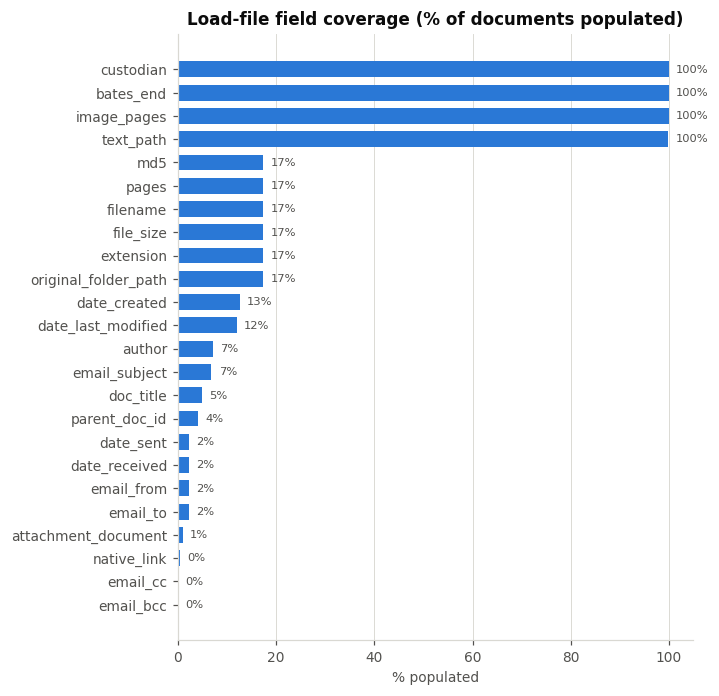

In [5]:
fill = (docs.notna().mean() * 100).round(1)
fill = fill[[c for c in [
    "custodian", "bates_end", "image_pages", "text_path", "md5", "pages", "filename",
    "file_size", "extension", "original_folder_path", "date_created", "date_last_modified",
    "author", "email_subject", "doc_title", "parent_doc_id", "date_sent", "date_received",
    "email_from", "email_to", "attachment_document", "native_link", "email_cc", "email_bcc",
] if c in docs]]

fig, ax = plt.subplots(figsize=(6.6, 6.4))
ax.barh(fill.index[::-1], fill.values[::-1], color=SEQ, height=0.68)
ax.set(title="Load-file field coverage (% of documents populated)", xlabel="% populated", xlim=(0, 105))
for name, v in zip(fill.index[::-1], fill.values[::-1]):
    ax.text(v + 1.5, name, f"{v:.0f}%", va="center", fontsize=7.5, color=INK_2)
ax.grid(axis="y", visible=False)
save(fig, "02_metadata_coverage")

In [6]:
print("custodian:", docs["custodian"].value_counts().to_dict())
print()
print("documents with an email sender in the LOAD FILE:", int(docs["email_from"].notna().sum()))
print("documents with any native file:               ", int(docs["has_native"].sum()))
print("documents flagged as an attachment:           ", int(docs["is_attachment"].sum()))
print()
print("file extension (where known):")
print(docs["extension"].value_counts().head(12).to_string())

custodian: {'Epstein, Jeffrey': 2897}

documents with an email sender in the LOAD FILE: 64
documents with any native file:                11
documents flagged as an attachment:            118

file extension (where known):
extension
pdf     263
msg      62
docx     37
doc      36
jpg      36
ps1      13
png      12
rtf      12
htm      10
jpeg      7
txt       7
pptx      3


**Finding 2.1 — the metadata is mostly empty, and uniform where it is not.**
Every document carries the same custodian (`Epstein, Jeffrey`), so custodian is a constant,
not a feature. Only ~17% of documents were produced as e-files with a filename, extension and
hash; the other ~83% are scans with nothing but Bates numbers and text.

**Finding 2.2 — the load file describes only 64 emails.** Any communication network built
from load-file fields alone would have at most 64 edges. Section 6 shows the production
actually contains *thousands* of emails — they are just printed to PDF, with their headers
living in the OCR text. **The graph has to be extracted from text, not from metadata.**

---
## 3. The text layer

Size and shape of what we actually feed to NER and to the retriever.

count      2897.0
mean       2520.0
std       11185.0
min           0.0
25%         172.0
50%         417.0
75%        1039.0
max      183051.0

299 documents (10.3%) hold 80% of all words
documents with <50 words: 211


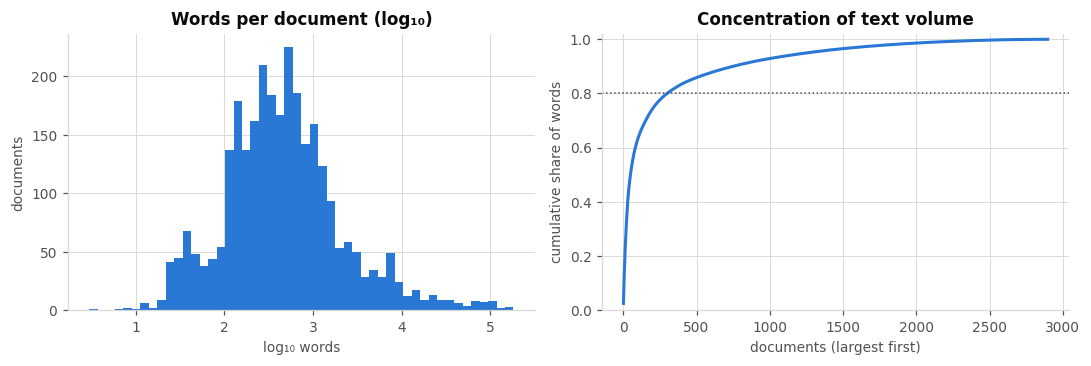

In [7]:
w = docs["n_words"].fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(np.log10(w[w > 0]), bins=50, color=SEQ)
axes[0].set(title="Words per document (log₁₀)", xlabel="log₁₀ words", ylabel="documents")
cum = np.sort(w)[::-1].cumsum() / w.sum()
axes[1].plot(np.arange(1, len(cum) + 1), cum, color=SEQ)
axes[1].set(title="Concentration of text volume", xlabel="documents (largest first)",
            ylabel="cumulative share of words", ylim=(0, 1.02))
axes[1].axhline(0.8, color=INK_2, lw=1, ls=":")
save(fig, "03_words_per_doc")

print(w.describe().round(0).to_string())
k = int(np.searchsorted(cum, 0.8) + 1)
print(f"\n{k} documents ({k/len(w):.1%}) hold 80% of all words")
print(f"documents with <50 words: {(w < 50).sum():,}")

---
## 4. Text quality — which documents can we actually read?

The production mixes clean digital exports with badly OCR'd scans of books, faxes and
photocopies. NER precision collapses on garbled text, so every document is scored up front
in `src/ingestion/textstats.py`.

An early version of this scoring collapsed everything into a single "quality" grade and got
it wrong: short emails and signature-block-heavy documents were graded `poor` purely for
containing few English function words, even though their text is perfect. The scoring is
therefore split into **two independent axes**, because they call for different treatment:

| Axis | Signals | What a bad score means |
|---|---|---|
| `ocr_quality` — character integrity | `no_vowel_type_ratio` (share of *distinct* 3+ letter word types with no vowel: `grnail`, `Xa-n.adu`), `nonword_char_ratio` (characters outside letters/digits/punctuation) | The characters themselves are wrong. Entities extracted here are untrustworthy. |
| `text_style` — composition | `common_word_ratio` (share of high-frequency English function words), only read above 150 words | The document is not running prose — a table, a recipient list, a JSON blob, or a page scan whose words were truncated at the line edge. |

Two details matter for the garble signal. URLs and email addresses are stripped before the
word-level metrics are computed — left in, they read as garble (`politico.com/story/2o17/o2/…`)
and drag clean documents down. And the vowel test counts *distinct word types*, not tokens: a
conference guest list that repeats the abbreviation `Fmr` 89 times is not damaged, whereas real
OCR damage produces many different nonsense tokens.

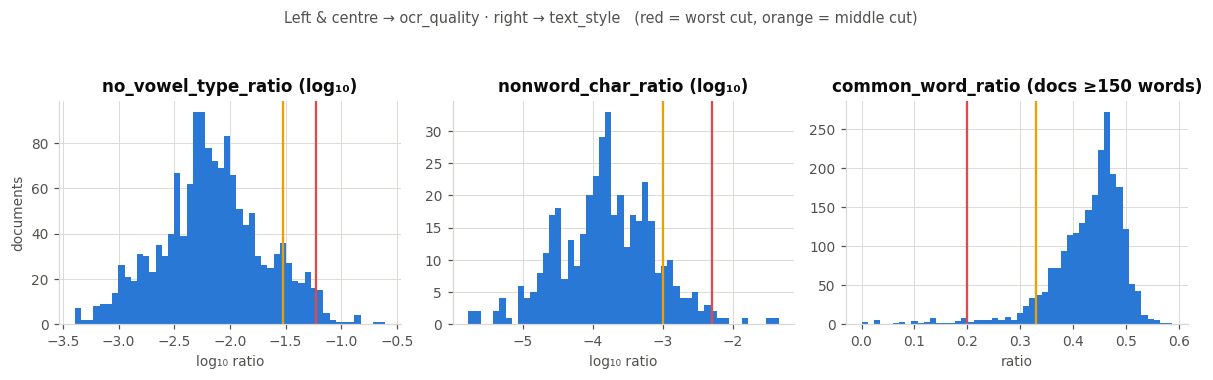

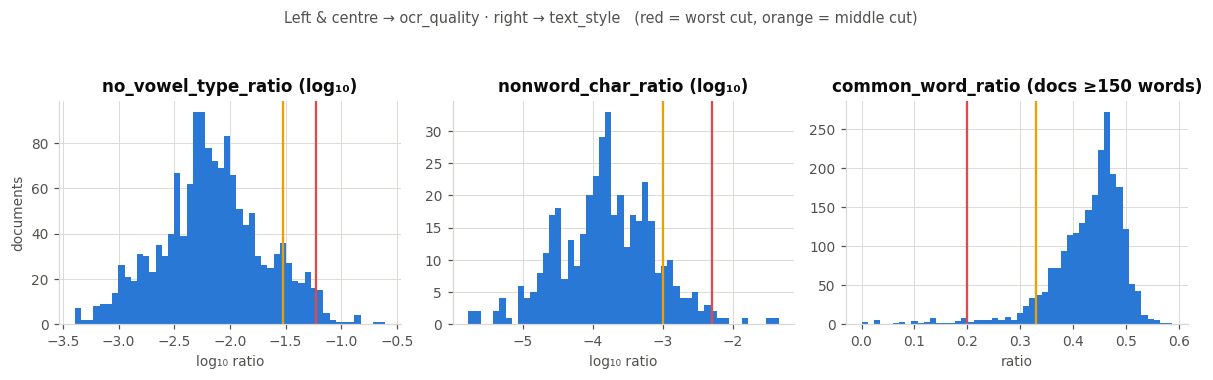

In [8]:
long_docs = docs[docs["n_words"] >= 150]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].hist(np.log10(docs["no_vowel_type_ratio"].replace(0, np.nan).dropna()), bins=50, color=SEQ)
axes[0].axvline(np.log10(0.06), color=SERIES[7], lw=1.5); axes[0].axvline(np.log10(0.03), color=SERIES[3], lw=1.5)
axes[0].set(title="no_vowel_type_ratio (log₁₀)", xlabel="log₁₀ ratio", ylabel="documents")
axes[1].hist(np.log10(docs["nonword_char_ratio"].replace(0, np.nan).dropna()), bins=50, color=SEQ)
axes[1].axvline(np.log10(0.005), color=SERIES[7], lw=1.5); axes[1].axvline(np.log10(0.001), color=SERIES[3], lw=1.5)
axes[1].set(title="nonword_char_ratio (log₁₀)", xlabel="log₁₀ ratio")
axes[2].hist(long_docs["common_word_ratio"], bins=50, color=SEQ)
axes[2].axvline(0.20, color=SERIES[7], lw=1.5); axes[2].axvline(0.33, color=SERIES[3], lw=1.5)
axes[2].set(title="common_word_ratio (docs ≥150 words)", xlabel="ratio")
fig.suptitle("Left & centre → ocr_quality · right → text_style   (red = worst cut, orange = middle cut)",
             y=1.06, fontsize=9.5, color=INK_2)
save(fig, "04_quality_metrics")

text_style   prose  short  mixed  sparse
ocr_quality                             
clean         2029    593    105      36
noisy           53     24     15       8
poor            18      8      2       5
empty            0      1      0       0

             n_words  common_word_ratio  no_vowel_type_ratio  nonword_char_ratio
ocr_quality                                                                     
clean          405.0             0.4401               0.0000                 0.0
empty            3.0             0.3333               0.0000                 0.0
noisy          795.0             0.3517               0.0341                 0.0
poor          1387.0             0.3324               0.0665                 0.0


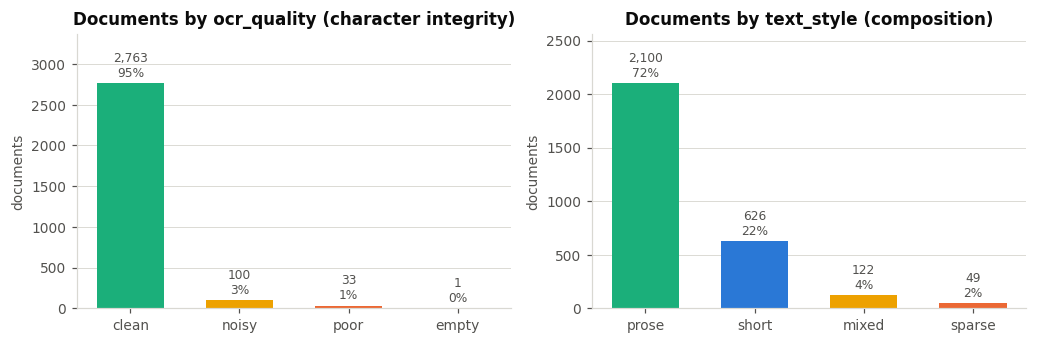

In [9]:
Q_ORDER = ["clean", "noisy", "poor", "empty"]
S_ORDER = ["prose", "short", "mixed", "sparse"]
q = docs["ocr_quality"].value_counts().reindex(Q_ORDER).fillna(0)
s = docs["text_style"].value_counts().reindex(S_ORDER).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].bar(Q_ORDER, q.values, color=[SERIES[2], SERIES[3], SERIES[1], SERIES[7]], width=0.62)
axes[0].set(title="Documents by ocr_quality (character integrity)", ylabel="documents")
axes[1].bar(S_ORDER, s.values, color=[SERIES[2], SERIES[0], SERIES[3], SERIES[1]], width=0.62)
axes[1].set(title="Documents by text_style (composition)", ylabel="documents")
for ax, vals in ((axes[0], q.values), (axes[1], s.values)):
    ax.set_ylim(0, vals.max() * 1.22)
    for i, v in enumerate(vals):
        ax.text(i, v + vals.max() * 0.03, f"{int(v):,}\n{v/len(docs):.0%}", ha="center",
                fontsize=8, color=INK_2)
    ax.grid(axis="x", visible=False)
save(fig, "05_quality_buckets")

print(pd.crosstab(docs["ocr_quality"], docs["text_style"]).reindex(
    index=[q for q in Q_ORDER if q in docs["ocr_quality"].values], columns=S_ORDER).to_string())
print()
print(docs.groupby("ocr_quality")[
    ["n_words", "common_word_ratio", "no_vowel_type_ratio", "nonword_char_ratio"]
].median().round(4).to_string())

In [10]:
# Read the buckets rather than trusting them.
for bucket in Q_ORDER:
    sub = docs[(docs["ocr_quality"] == bucket) & docs["text_path"].notna()]
    if sub.empty:
        continue
    row = sub.sample(1, random_state=7).iloc[0]
    print(f"===== ocr_quality={bucket}  {row.name}  ({int(row.n_words)} words) ".ljust(100, "="))
    print(load_text(row["text_path"])[:300].replace("\n", " ⏎ "), "\n")

for row_ in [docs[(docs["text_style"] == st) & docs["text_path"].notna()].sample(1, random_state=5).iloc[0]
             for st in ("sparse", "mixed")]:
    print(f"===== text_style={row_.text_style}  {row_.name}  ({int(row_.n_words)} words) ".ljust(100, "="))
    print(load_text(row_["text_path"])[:300].replace("\n", " ⏎ "), "\n")

===== ocr_quality=clean  HOUSE_OVERSIGHT_030464  (1361 words) ======================================
From:  ⏎ Sent:  ⏎ To:  ⏎ Subject:  ⏎ Attachments:  ⏎ Jessica Cadwell, Paralegal _________________________________  ⏎ 3/8/2011 8:49:29 PM  ⏎ Jeffrey Epstein [jeeyacation@gmail.com]  ⏎ RE:  ⏎ bc1c.gif  ⏎ Importance: High  ⏎ That's actually a very well written article, and I suspect very true and from the heart.  ⏎ I was thin 

===== ocr_quality=noisy  HOUSE_OVERSIGHT_027275  (226 words) =======================================
Source Entr: H\Macintosh HD\root\Users\jee\Library\Messages\Archive\2018-04-10\+1  ⏎ on 2018-04-10 at 07.09.05.ichat  ⏎ Service: iMessage  ⏎ Start Time: 04/10/18 04:09:05 AM (545051345)  ⏎ End Time: 04/10/18 08:31:33 AM (545067093)  ⏎ Last Message ID: 14654  ⏎ Chat Room:  ⏎ Participants: jee, ____________________ 

===== ocr_quality=poor  HOUSE_OVERSIGHT_015529  (15141 words) ======================================
10/5/2015 Jeffrey Epstein 'sex slave' Virginia Robert

**Finding 4.1 — character-level OCR damage is rare; non-prose documents are not.**
Only a small tail of documents is genuinely garbled, and that tail is where NER will invent
entities: nonsense tokens still get typed as PERSON or ORG with high confidence. Those
documents are excluded from extraction (`usable == False`); everything else is kept with its
flag carried through to the chunk level so retrieval can filter on it.

**Finding 4.2 — the `sparse` bucket is a review flag, not a verdict.** It mixes genuinely
useless material (JSON blobs, repeated redaction pages) with perfectly good non-prose
content (event programmes, recipient lists). It also catches the one failure mode the
character metrics cannot see: book and newspaper scans whose words were truncated at the
line edge, where every character is a valid letter but the words are fragments.

**Finding 4.3 — OCR corrupts the identifiers we most need.** The same Gmail address appears
as `jeevacation@gmail.com`, `jeeyacation@gmail.com`, `jeevacation@qmail.com` and
`jeevacation@grnail.corn`. Entity resolution is therefore not just an alias problem ("Jeff"
vs "Jeffrey Epstein") but a *character-level noise* problem, and it needs fuzzy matching,
not a lookup table.

---
## 5. What kinds of documents are these?

There is no document-type field, so types are assigned with regex families over the text
(`DOC_TYPE_PATTERNS`). This is weak labelling — a document can match several families, and a
court exhibit containing a printed email legitimately matches both.

documents matching ≥1 family: 2,629 (90.7%)
documents matching ≥3 families: 152


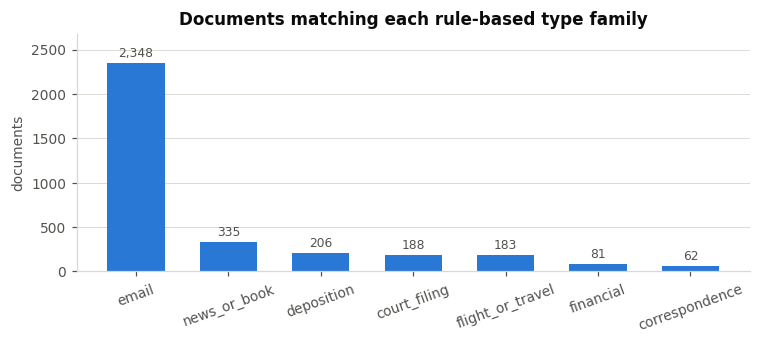

In [11]:
types = docs["doc_types"].fillna("").str.split("|").explode()
types = types[types != ""].value_counts()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(types.index, types.values, color=SEQ, width=0.62)
ax.set(title="Documents matching each rule-based type family", ylabel="documents")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="x", visible=False)
ax.set_ylim(0, types.values.max() * 1.14)
for i, v in enumerate(types.values):
    ax.text(i, v + types.values.max() * 0.03, f"{v:,}", ha="center", fontsize=8, color=INK_2)
save(fig, "06_doc_types")

n_typed = (docs["doc_types"].fillna("") != "").sum()
print(f"documents matching ≥1 family: {n_typed:,} ({n_typed/len(docs):.1%})")
print(f"documents matching ≥3 families: {(docs['doc_types'].fillna('').str.count('\\|') >= 2).sum():,}")

---
## 6. The email network hiding in the text

Section 2 showed the load file tags only 64 emails. But thousands of documents are emails
that were *printed*, so their `From: / Sent: / To: / Subject:` block survives in the OCR
text. `src/ingestion/email_headers.py` parses those blocks — including forwarded chains
nested inside a single document.

This is the single most important finding in the EDA: it means a substantial, high-precision
slice of the knowledge graph can be built **deterministically**, before any LLM extraction,
and can then serve as ground truth for evaluating the LLM/spaCy pipelines in Phase 2.

In [12]:
from src.ingestion.email_headers import edge_list, messages_to_frame, parse_headers

messages = []
for doc_id, path in docs["text_path"].dropna().items():
    messages.extend(parse_headers(doc_id, load_text(path)))

msg_df = messages_to_frame(messages)
edges = edge_list(messages)

print(f"header blocks parsed        {len(msg_df):>8,}")
print(f"documents containing ≥1     {msg_df['doc_id'].nunique():>8,}  ({msg_df['doc_id'].nunique()/len(docs):.0%} of corpus)")
print(f"forwarded/nested blocks     {int(msg_df['is_forwarded'].sum()):>8,}")
print(f"sender→recipient edges      {len(edges):>8,}")
print(f"unique directed pairs       {edges.groupby(['source','target']).ngroups:>8,}")
print(f"distinct actors             {len(set(edges['source']) | set(edges['target'])):>8,}")
print(f"\n(load file reported {int(docs['email_from'].notna().sum())} emails)")

header blocks parsed           4,039
documents containing ≥1        2,208  (76% of corpus)
forwarded/nested blocks          498
sender→recipient edges         4,088
unique directed pairs          1,421
distinct actors                  984

(load file reported 64 emails)


Raw sender addresses — note the OCR variants of a single mailbox:
sender_address
jeevacation@gmail.com              661
jeeyacation@gmail.com              390
jeevacation@qmail.com               17
us.gio@jpmorgan.com                 13
editorialstaff@flipboard.com        13
jeevacation@dmail.com               12
gmax1@ellmax.com                    11
gmaxl@ellmax.com                    11
jeevacation@omail.com                9
sedelman@nypost.com                  7
googlealerts-noreply@google.com      7
digest-noreply@quora.com             5


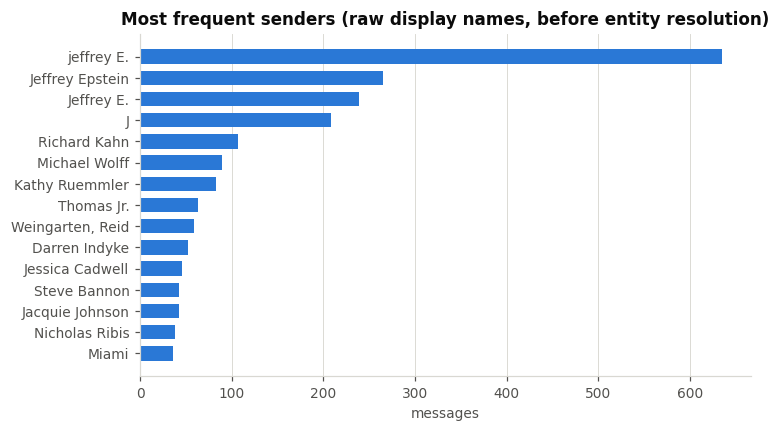

In [13]:
top_senders = msg_df["sender_name"].dropna().value_counts().head(15)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_senders.index[::-1], top_senders.values[::-1], color=SEQ, height=0.68)
ax.set(title="Most frequent senders (raw display names, before entity resolution)", xlabel="messages")
ax.grid(axis="y", visible=False)
save(fig, "07_top_senders")

print("Raw sender addresses — note the OCR variants of a single mailbox:")
print(msg_df["sender_address"].value_counts().head(12).to_string())

nodes 984  edges 1,421  density 0.00147
weakly connected components: 47  (largest holds 814 actors)


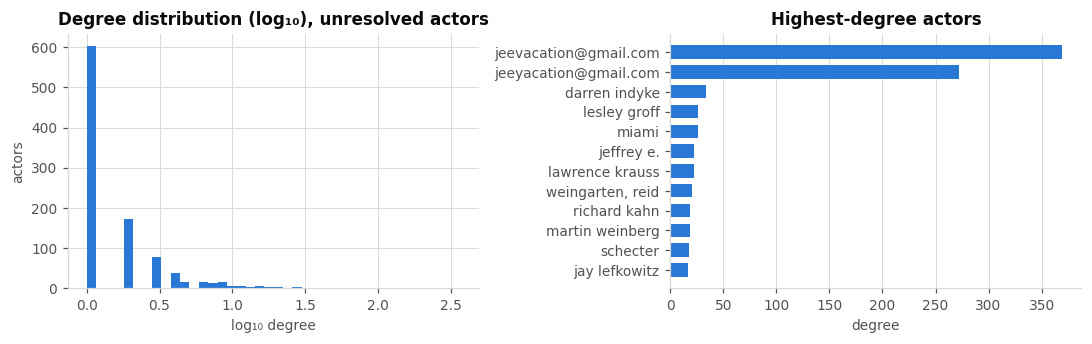

In [14]:
# Preview the network that these edges imply — degree distribution only; the real
# graph work is Phase 3, and this is deliberately built on un-resolved identifiers.
import networkx as nx

G = nx.from_pandas_edgelist(edges, "source", "target", create_using=nx.DiGraph)
deg = pd.Series(dict(G.degree())).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(np.log10(deg[deg > 0]), bins=40, color=SEQ)
axes[0].set(title="Degree distribution (log₁₀), unresolved actors", xlabel="log₁₀ degree", ylabel="actors")
top = deg.head(12)
axes[1].barh([t[:28] for t in top.index[::-1]], top.values[::-1], color=SEQ, height=0.68)
axes[1].set(title="Highest-degree actors", xlabel="degree")
axes[1].grid(axis="y", visible=False)
save(fig, "08_email_degree")

print(f"nodes {G.number_of_nodes():,}  edges {G.number_of_edges():,}  density {nx.density(G):.5f}")
comps = list(nx.weakly_connected_components(G))
print(f"weakly connected components: {len(comps)}  (largest holds {max(len(c) for c in comps):,} actors)")

**Finding 6.1 — the email layer is real and large.** Thousands of header blocks across a
majority of the corpus, versus 64 in the metadata.

**Finding 6.2 — the network is dominated by aliasing, not by structure.** The top-degree
"actors" include several spellings of the same mailbox and bare first names (`J`,
`jeffrey E.`). The raw degree distribution is therefore an artefact of unresolved
identities. **Entity resolution has to happen before any centrality number is
interpretable** — which makes Phase 2's resolution step a prerequisite for Phase 3, not a
nicety.

---
## 7. Temporal coverage

Dates come from three places, in decreasing reliability: load-file `Date Sent` (64 docs),
`Date Created` (metadata for e-files), and dates parsed out of email headers in the text.

dropped 2 dates outside 1995–2025 (OCR damage on the year digits)
header date strings: 3,960 → parsed 3,922 (99%)


email-header dates : 2006-07-24 → 2019-07-16
date_created       : 2005-03-21 → 2025-03-17

messages per year (headers):
sent_raw
2006     16
2007     19
2008     20
2009    145
2010    110
2011    290
2012     88
2013    113
2014    146
2015    409
2016    775
2017    740
2018    744
2019    307


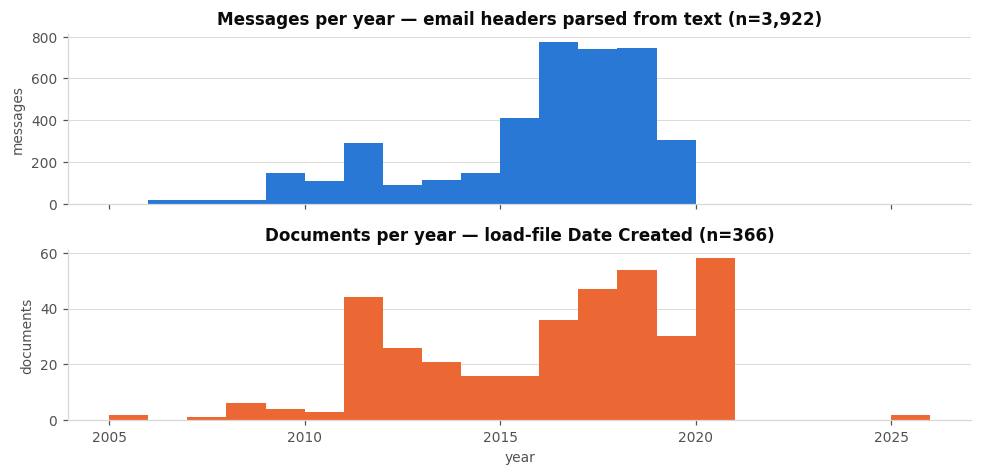

In [15]:
from dateutil import parser as dateparser


YEAR_RE = re.compile(r"\b(19|20)\d{2}\b")


def parse_loose(value):
    """Header dates come in a dozen OCR-mangled formats; parse what we can.

    A 4-digit year must be present, otherwise dateutil silently invents one.
    """
    if not YEAR_RE.search(value):
        return pd.NaT
    try:
        ts = pd.Timestamp(dateparser.parse(value, fuzzy=True))
        return ts.tz_localize(None) if ts.tzinfo else ts
    except Exception:
        return pd.NaT


sent_meta = docs["date_sent"].dropna()
created = docs["date_created"].dropna()
raw_dates = msg_df["sent_raw"].dropna()
lookup = {v: parse_loose(v) for v in raw_dates.unique()}
hdr = pd.to_datetime(raw_dates.map(lookup), errors="coerce").dropna()
implausible = ((hdr.dt.year < 1995) | (hdr.dt.year > 2025)).sum()
hdr = hdr[(hdr.dt.year >= 1995) & (hdr.dt.year <= 2025)]
print(f"dropped {implausible} dates outside 1995–2025 (OCR damage on the year digits)")
print(f"header date strings: {len(raw_dates):,} → parsed {len(hdr):,} ({len(hdr)/len(raw_dates):.0%})")

years = np.arange(2005, 2027)
fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True)
axes[0].hist(hdr.dt.year, bins=years, color=SERIES[0])
axes[0].set(title=f"Messages per year — email headers parsed from text (n={len(hdr):,})", ylabel="messages")
axes[1].hist(created.dt.year, bins=years, color=SERIES[1])
axes[1].set(title=f"Documents per year — load-file Date Created (n={len(created):,})",
            xlabel="year", ylabel="documents")
for ax in axes:
    ax.grid(axis="x", visible=False)
save(fig, "09_temporal")

print("email-header dates :", hdr.min().date(), "→", hdr.max().date())
print("date_created       :", created.min().date(), "→", created.max().date())
print("\nmessages per year (headers):")
print(hdr.dt.year.value_counts().sort_index().to_string())

---
## 8. Redactions, families and duplicates

Three practical hazards for retrieval: redacted spans that look like content, attachment
families that must stay linked, and near-duplicate documents that would otherwise dominate
top-k retrieval.

In [16]:
red = docs["n_redaction_marks"].fillna(0)
print(f"documents with ≥1 redaction mark: {(red > 0).sum():,} ({(red > 0).mean():.1%})")
print(f"total redaction marks:            {int(red.sum()):,}")
print(f"\nattachment families (docs with a parent): {int(docs['is_attachment'].sum()):,}")
print(f"documents that are a parent:              {docs['parent_doc_id'].dropna().nunique():,}")

exact = docs["md5"].dropna()
print(f"\nexact duplicates by shipped MD5: {exact.duplicated().sum()} (only {len(exact):,} docs carry a hash)")

# Text-level duplicates, which the MD5 field cannot see because most docs are scans.
import hashlib
norm = docs["text_path"].dropna().map(
    lambda p: hashlib.md5(" ".join(strip_bates(load_text(p)).split()).lower().encode()).hexdigest()
)
dupe_groups = norm.value_counts()
dupe_groups = dupe_groups[dupe_groups > 1]
print(f"exact-text duplicate groups:  {len(dupe_groups):,} covering {int(dupe_groups.sum()):,} documents")
print(f"documents that are a redundant copy: {int((dupe_groups - 1).sum()):,}")

documents with ≥1 redaction mark: 982 (33.9%)
total redaction marks:            4,502

attachment families (docs with a parent): 118
documents that are a parent:              74

exact duplicates by shipped MD5: 3 (only 505 docs carry a hash)


exact-text duplicate groups:  16 covering 32 documents
documents that are a redundant copy: 16


**Finding 8.1 — deduplicate on normalised text, not on the shipped hash.** Only 17% of
documents carry an MD5, and Bates stamps make otherwise-identical scans differ byte-for-byte.
Normalising whitespace, case and Bates stamps first is what actually finds the copies.

**Finding 8.2 — redaction marks are pervasive.** They must be normalised to a sentinel token
before chunking, or the retriever will happily match on runs of underscores and NER will
attach the redaction to whatever name precedes it.

---
## 9. A first look at entity density

No NER yet — just a capitalised-span regex, to size the problem and sanity-check that the
people we would expect are actually present and frequent enough to anchor a graph.

distinct capitalised spans: 68,138
spans occurring ≥10 times:  2,384
spans in ≥10 documents:     802



spans whose mention count is inflated by repetition inside few documents:
                               mentions  documents  mentions_per_doc
Is Read                          2942.0         60              49.0
Is Invitation                    2942.0         60              49.0
Merrill Lynch Global Research     747.0         20              37.4
Merrill Lynch                    1182.0         41              28.8
Hong Kong                        1034.0         64              16.2
West Bank                         356.0         31              11.5
Jane Doe                          905.0         88              10.3
United States                    2850.0        286              10.0


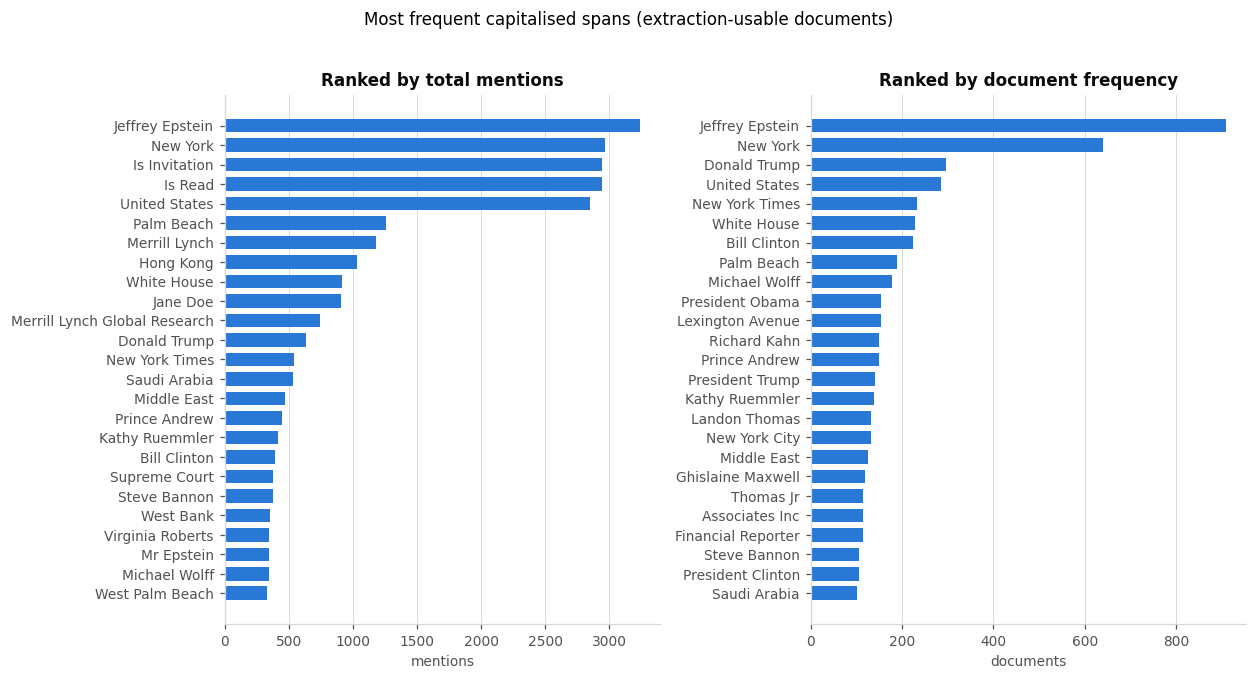

In [17]:
import re
from collections import Counter

CAP_SPAN = re.compile(r"\b(?:[A-Z][a-z]{1,15}\s){1,3}[A-Z][a-z]{1,15}\b")
STOP_STARTS = ("The ", "This ", "That ", "In ", "On ", "For ", "It ", "We ", "I ", "A ", "And ")

mentions, doc_freq = Counter(), Counter()
usable = docs[docs["usable"] & docs["text_path"].notna()]
for path in usable["text_path"]:
    text = strip_bates(load_text(path))
    seen = set()
    for span in CAP_SPAN.findall(text):
        span = span.strip()
        if span.startswith(STOP_STARTS) or len(span) < 6:
            continue
        mentions[span] += 1
        seen.add(span)
    for span in seen:
        doc_freq[span] += 1

print(f"distinct capitalised spans: {len(mentions):,}")
print(f"spans occurring ≥10 times:  {sum(v >= 10 for v in mentions.values()):,}")
print(f"spans in ≥10 documents:     {sum(v >= 10 for v in doc_freq.values()):,}")

# Raw mention counts are dominated by boilerplate repeated inside a single export
# ("Is Read", "Is Invitation" come from .msg field labels), so rank by the number of
# documents a span appears in instead.
by_mentions = pd.Series(mentions).sort_values(ascending=False).head(25)
by_docs = pd.Series(doc_freq).sort_values(ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 6))
axes[0].barh(by_mentions.index[::-1], by_mentions.values[::-1], color=SEQ, height=0.7)
axes[0].set(title="Ranked by total mentions", xlabel="mentions")
axes[1].barh(by_docs.index[::-1], by_docs.values[::-1], color=SEQ, height=0.7)
axes[1].set(title="Ranked by document frequency", xlabel="documents")
for ax in axes:
    ax.grid(axis="y", visible=False)
fig.suptitle("Most frequent capitalised spans (extraction-usable documents)", y=1.02, fontsize=11)
save(fig, "10_entity_candidates")

inflation = pd.DataFrame({"mentions": by_mentions, "documents": pd.Series(doc_freq)}).dropna()
inflation["mentions_per_doc"] = (inflation["mentions"] / inflation["documents"]).round(1)
print("\nspans whose mention count is inflated by repetition inside few documents:")
print(inflation.sort_values("mentions_per_doc", ascending=False).head(8).to_string())

count    2861.0
mean       84.9
std       334.9
min         0.0
25%         5.0
50%        13.0
75%        42.0
max      5391.0


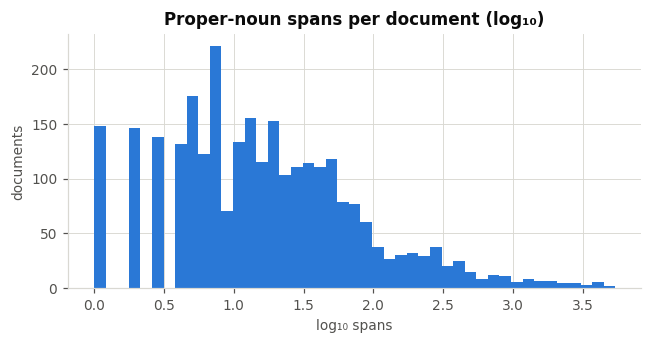

In [18]:
# Mentions per document — a rough upper bound on nodes-per-document for the graph.
per_doc = usable["n_proper_noun_spans"].fillna(0)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(np.log10(per_doc[per_doc > 0]), bins=45, color=SEQ)
ax.set(title="Proper-noun spans per document (log₁₀)", xlabel="log₁₀ spans", ylabel="documents")
save(fig, "11_spans_per_doc")
print(per_doc.describe().round(1).to_string())

---
## 10. Sizing Phases 1–4

What the numbers above imply for chunking, embedding and extraction cost.

In [19]:
CHUNK_WORDS, OVERLAP = 350, 60
usable_words = docs.loc[docs["usable"], "n_words"].fillna(0)
chunks = np.ceil(np.maximum(usable_words - OVERLAP, 0) / (CHUNK_WORDS - OVERLAP)).sum()

print(f"corpus words (all)                {int(docs['n_words'].sum()):>10,}")
print(f"corpus words (extraction-usable)  {int(usable_words.sum()):>10,}")
print(f"≈ chunks at {CHUNK_WORDS} words / {OVERLAP} overlap  {int(chunks):>10,}")
print(f"≈ tokens to embed (×1.35)         {int(usable_words.sum() * 1.35):>10,}")
print(f"\ndocuments an LLM extractor would see: {int(docs['usable'].sum()):,}")
print(f"deterministic email edges already available: {len(edges):,}")

corpus words (all)                 7,299,554
corpus words (extraction-usable)   7,167,462
≈ chunks at 350 words / 60 overlap      25,534
≈ tokens to embed (×1.35)          9,676,073

documents an LLM extractor would see: 2,863
deterministic email edges already available: 4,088


---
## 11. What this means for the project plan

**Phase 1 — corpus.** The unit is the document (beginning Bates); pages come from the `.opt`,
not from the sparse `Pages` field. Before chunking: strip burned-in Bates stamps, normalise
redaction runs to a sentinel, drop the `empty` bucket, and quarantine the `poor` bucket
behind a quality flag carried on every chunk. Deduplicate on normalised text.

**Phase 2 — knowledge graph.** Build it in two tiers:
1. *Deterministic tier* — email headers parsed from text give thousands of
   `communicated with` edges with exact document provenance, at essentially zero cost and
   near-perfect precision.
2. *Model tier* — spaCy / LLM extraction over the extraction-usable documents for the relationship
   types headers cannot give us (`traveled with`, `employed by`, `represented by`).

   Tier 1 doubles as **labelled data for the extraction evaluation** the plan calls for:
   any extractor that misses the sender/recipient pair of an email it was shown is
   demonstrably under-recalling.

   Entity resolution must handle character-level OCR noise (`grnail.corn`), not just aliases.
   It is a prerequisite for Phase 3, since raw degree is currently an aliasing artefact.

**Phase 3 — network analysis.** Report every centrality both before and after entity
resolution; the delta is itself a result. Weight edges by message count and carry the
document IDs as edge evidence so Phase 4 can cite them.

**Phase 4 — GraphRAG vs RAG.** The email layer supplies natural multi-hop evaluation
questions with verifiable answers ("who connects A and B", "which documents support it"),
because the ground-truth path is reconstructable from the parsed headers. Chunk metadata
should carry `doc_id`, page range, `ocr_quality`, `text_style` and `doc_types` so retrieved evidence can be
filtered and cited.